Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


Load Dataset

In [4]:
# Load dataset
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

# Display first 5 rows
print(df.head())

# Dataset information
print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21   

   Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_pH  \
0        486.4               24.3          69.1                 5.8     7.14   
1        855.4               25.7          78.4                 5.1     5.20   
2        455.6               23.9          56.4                10.3     5.82   
3        753.2               29.7          65.2                 6.3     5.98   
4        101.6               34.1          55.2                 6.5     6.90   

   Soil_Moisture_pct  Nitrogen_kg_ha  Phosphorus_kg_ha  Potass

Understand the Dataset

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (4000, 28)

Column Names:
1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct

Data Types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Statistical Summary:


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


Data Quality and Cleaning

In [6]:
print("Missing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nUnique Values:")
display(df.nunique().to_frame("Unique Values"))

# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

print("\nDataset after cleaning:", df.shape)

Missing Values:


,Missing Values
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0



Duplicate Records:
0

Unique Values:


,Unique Values
Farm_ID,4000
State,8
District,10
Crop,8
Season,3
Farm_Area_Hectares,1370
Rainfall_mm,3256
Avg_Temperature_C,204
Humidity_pct,573
Sunlight_Hours_Day,71



Dataset after cleaning: (4000, 28)


Seasonal Distribution

,Season,Number_of_Records
0,Kharif,1779
1,Rabi,1627
2,Zaid,594


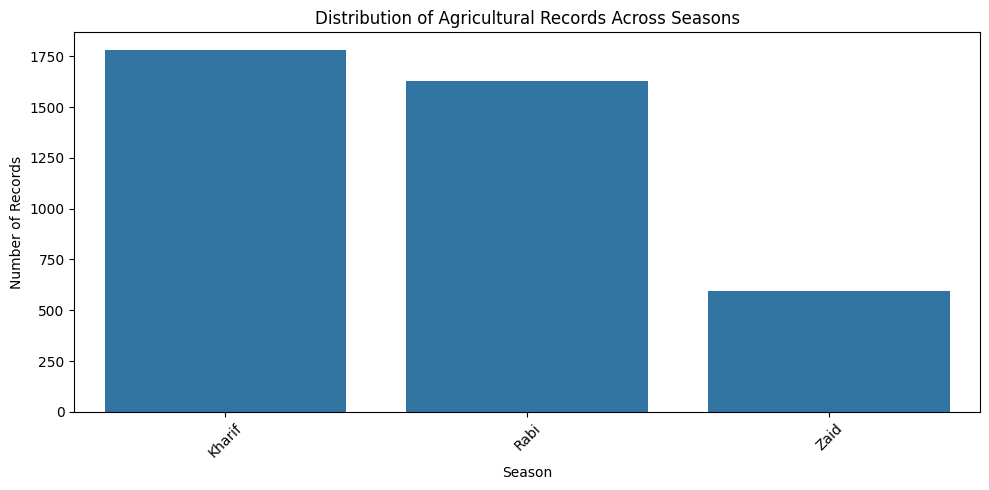

In [7]:
season_counts = (
    df["Season"]
    .value_counts()
    .reset_index()
)

season_counts.columns = ["Season", "Number_of_Records"]

display(season_counts)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=season_counts,
    x="Season",
    y="Number_of_Records"
)

plt.title("Distribution of Agricultural Records Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("01_season_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Seasonal Yield, Production and Profit

In [8]:
seasonal_performance = (
    df.groupby("Season")
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Production=("Production_Tonnes", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .round(2)
    .reset_index()
)

display(seasonal_performance)

,Season,Average_Yield,Average_Production,Average_Profit
0,Kharif,5.64,46.31,178914.65
1,Rabi,5.08,41.49,87689.47
2,Zaid,4.67,38.89,-24804.82


Yield visualization

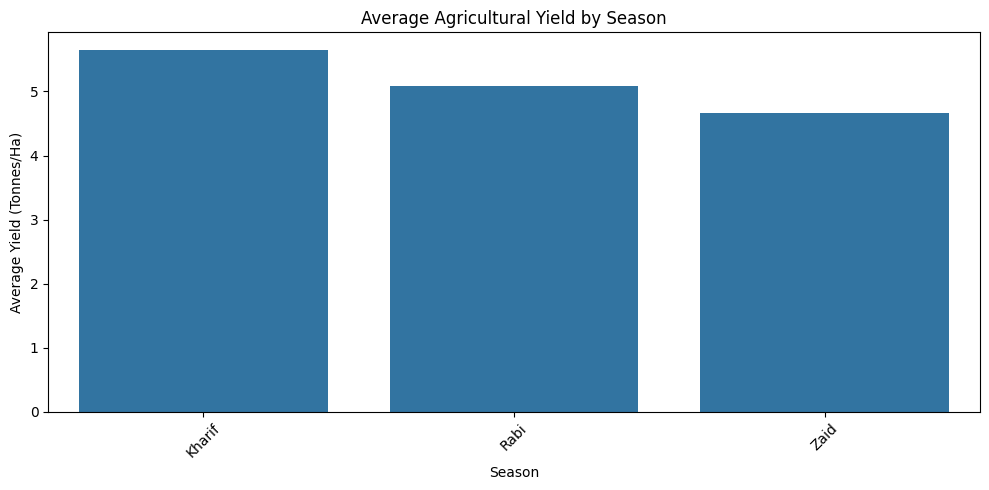

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=seasonal_performance,
    x="Season",
    y="Average_Yield"
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("02_seasonal_yield.png", dpi=300, bbox_inches="tight")
plt.show()

Yield Distribution

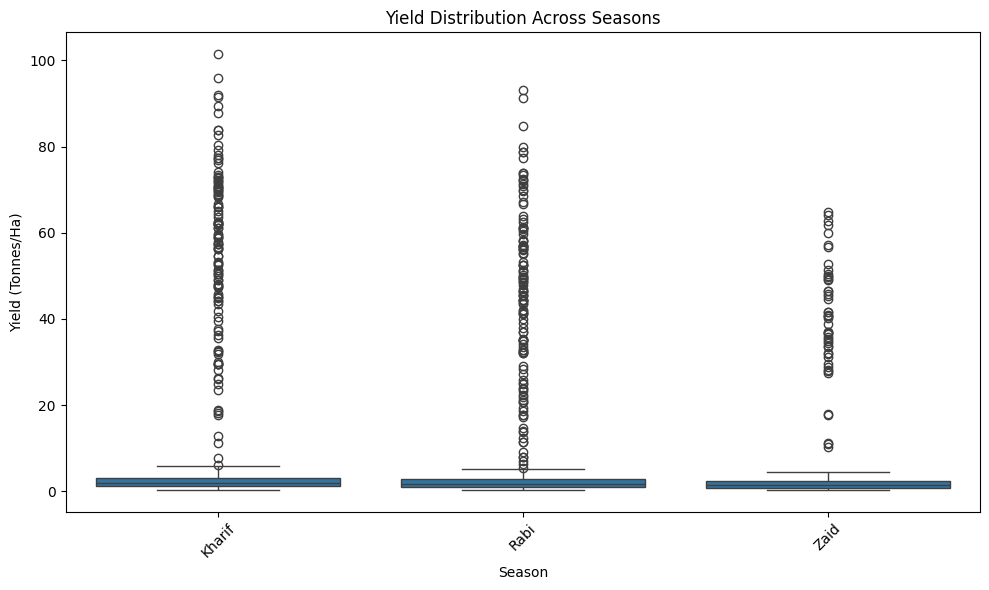

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("03_yield_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Statistical Significance using ANOVA

In [11]:
season_groups = [
    group["Yield_Tonnes_Ha"].dropna()
    for _, group in df.groupby("Season")
]

anova_result = stats.f_oneway(*season_groups)

print("ANOVA Statistic:", round(anova_result.statistic, 4))
print("P-value:", round(anova_result.pvalue, 6))

if anova_result.pvalue < 0.05:
    print("\nConclusion:")
    print("Yield differences across seasons are statistically significant.")
else:
    print("\nConclusion:")
    print("No statistically significant difference in yield was detected across seasons.")

ANOVA Statistic: 1.458
P-value: 0.232835

Conclusion:
No statistically significant difference in yield was detected across seasons.


Environmental Conditions

In [12]:
environmental_analysis = (
    df.groupby("Season")
    .agg(
        Rainfall=("Rainfall_mm", "mean"),
        Temperature=("Avg_Temperature_C", "mean"),
        Humidity=("Humidity_pct", "mean"),
        Sunlight=("Sunlight_Hours_Day", "mean"),
        Soil_Moisture=("Soil_Moisture_pct", "mean")
    )
    .round(2)
    .reset_index()
)

display(environmental_analysis)

,Season,Rainfall,Temperature,Humidity,Sunlight,Soil_Moisture
0,Kharif,852.08,28.45,71.81,6.79,31.20
1,Rabi,436.00,23.49,57.89,7.59,24.05
2,Zaid,299.42,31.04,52.01,8.18,19.17


Environmental factors vs yield

In [13]:
environmental_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]

environmental_corr = (
    df[environmental_cols + ["Yield_Tonnes_Ha"]]
    .corr()["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

display(environmental_corr)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Rainfall_mm,0.030853
Humidity_pct,0.011277
Soil_Moisture_pct,0.010210
Avg_Temperature_C,0.009349
Sunlight_Hours_Day,-0.015362


Visualization

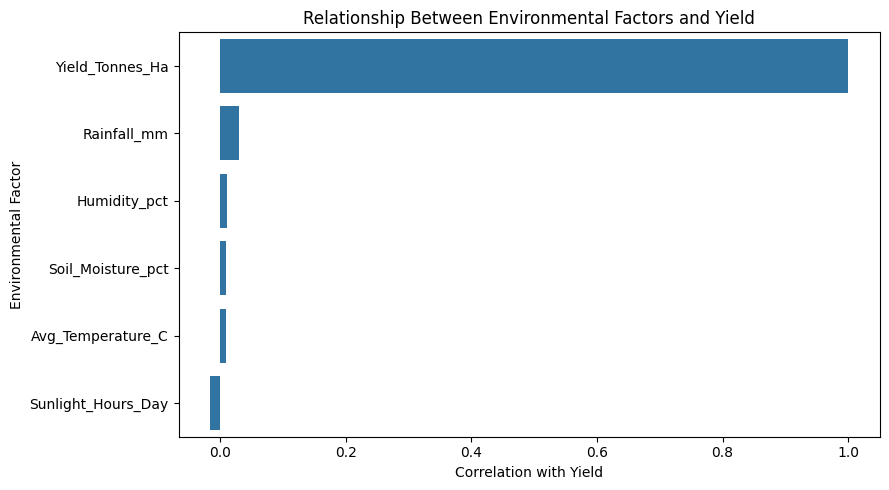

In [22]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=environmental_corr.values,
    y=environmental_corr.index
)

plt.title("Relationship Between Environmental Factors and Yield")
plt.xlabel("Correlation with Yield")
plt.ylabel("Environmental Factor")
plt.tight_layout()

plt.savefig("04_environment_yield_relationship.png", dpi=300, bbox_inches="tight")
plt.show()

Rainfall vs Yield

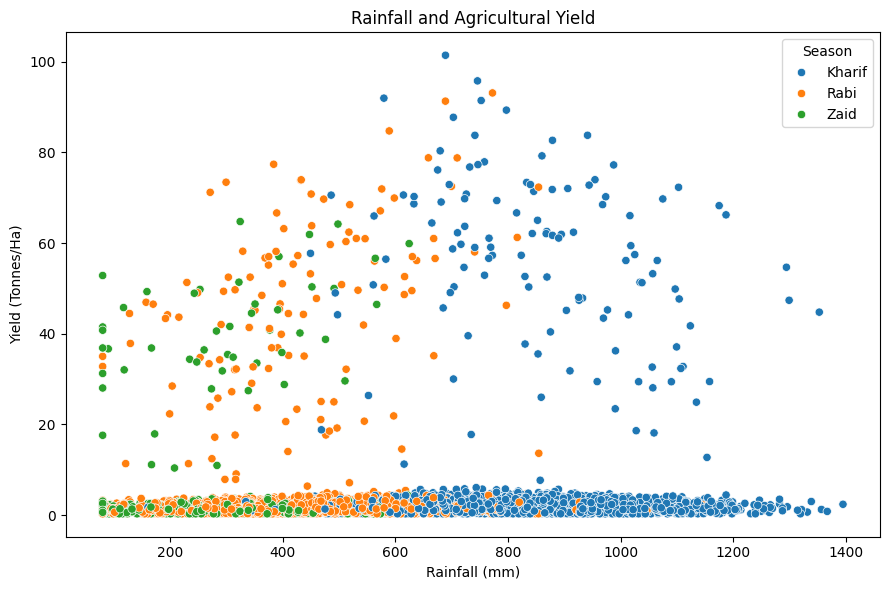

In [16]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall and Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()

plt.savefig("05_rainfall_vs_yield.png", dpi=300, bbox_inches="tight")
plt.show()

Resource Utilization

In [17]:
resource_analysis = (
    df.groupby("Season")
    .agg(
        Fertilizer=("Fertilizer_kg_ha", "mean"),
        Pesticide=("Pesticide_Litre_ha", "mean"),
        Water_Used=("Water_Used_m3", "mean"),
        Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
    )
    .round(2)
    .reset_index()
)

display(resource_analysis)

,Season,Fertilizer,Pesticide,Water_Used,Water_Efficiency
0,Kharif,187.08,5.08,6102.20,5.89
1,Rabi,185.41,5.02,5846.99,5.19
2,Zaid,184.64,5.17,6419.89,4.41


Water-use efficiency chart

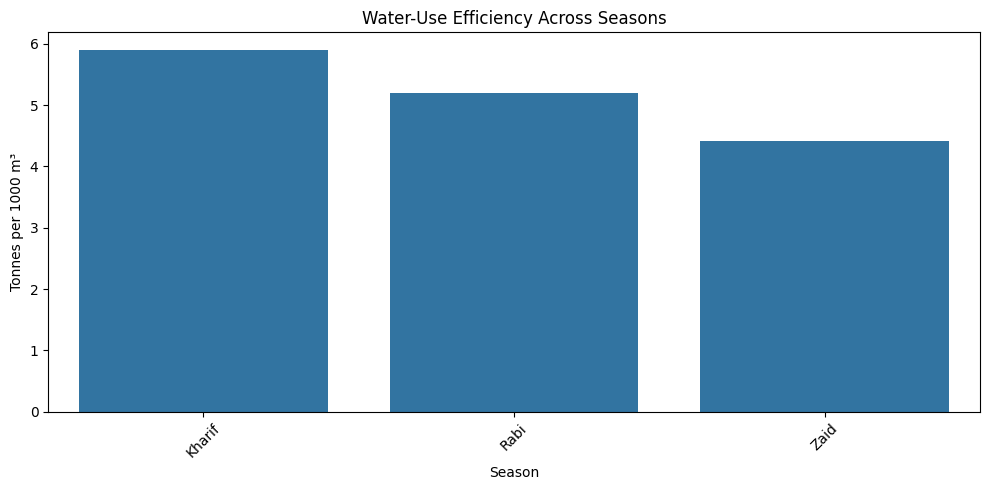

In [18]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=resource_analysis,
    x="Season",
    y="Water_Efficiency"
)

plt.title("Water-Use Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("06_water_efficiency.png", dpi=300, bbox_inches="tight")
plt.show()

Irrigation Method vs Yield

In [19]:
irrigation_analysis = (
    df.groupby(["Season", "Irrigation_Method"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Water_Use=("Water_Used_m3", "mean")
    )
    .round(2)
    .reset_index()
)

display(irrigation_analysis)

,Season,Irrigation_Method,Average_Yield,Average_Water_Use
0,Kharif,Drip,7.26,5953.37
1,Kharif,Flood,5.00,8229.27
2,Kharif,Rainfed,5.72,3687.52
3,Kharif,Sprinkler,4.67,5863.27
4,Rabi,Drip,6.21,5911.41
5,Rabi,Flood,5.10,7766.83
6,Rabi,Rainfed,3.94,3298.29
7,Rabi,Sprinkler,5.36,6129.09
8,Zaid,Drip,5.85,5837.99
9,Zaid,Flood,4.03,8113.69


Visualization

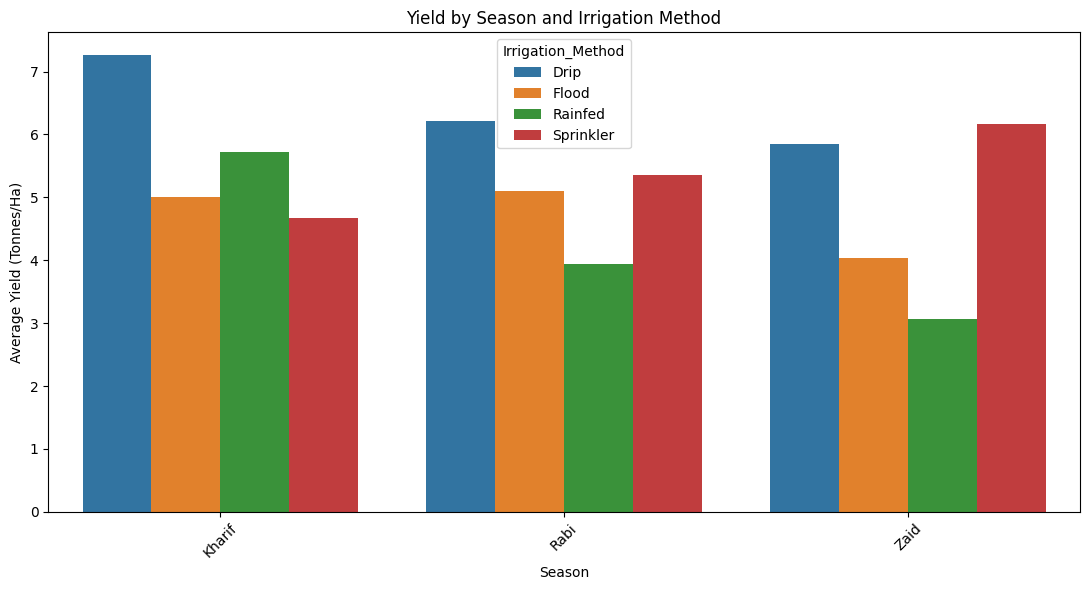

In [20]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=irrigation_analysis,
    x="Season",
    y="Average_Yield",
    hue="Irrigation_Method"
)

plt.title("Yield by Season and Irrigation Method")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("07_irrigation_yield.png", dpi=300, bbox_inches="tight")
plt.show()

Economic Performance

In [21]:
economic_analysis = (
    df.groupby("Season")
    .agg(
        Average_Cost=("Total_Cost_INR", "mean"),
        Average_Revenue=("Revenue_INR", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .round(2)
    .reset_index()
)

display(economic_analysis)

,Season,Average_Cost,Average_Revenue,Average_Profit
0,Kharif,531804.41,710719.06,178914.65
1,Rabi,513836.58,601526.05,87689.47
2,Zaid,543976.73,519171.90,-24804.82


Profit visualization

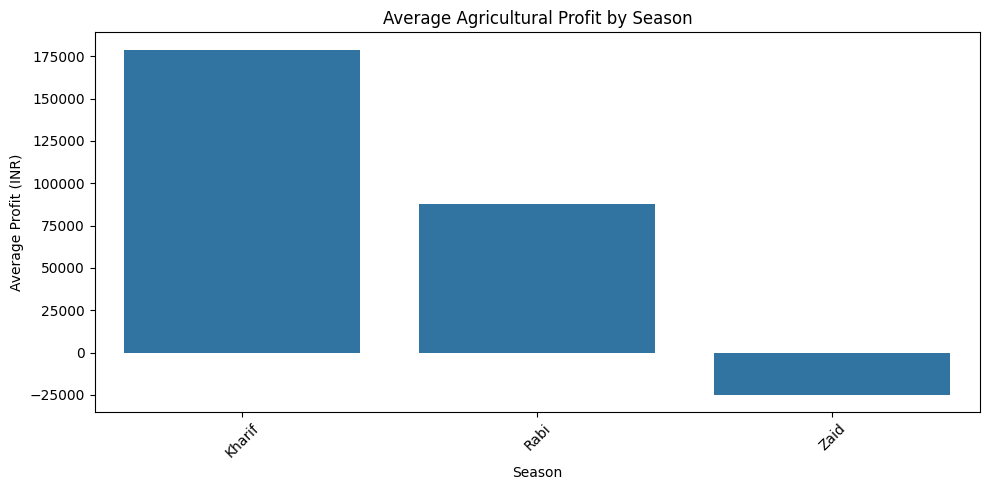

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=economic_analysis,
    x="Season",
    y="Average_Profit"
)

plt.title("Average Agricultural Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("08_seasonal_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Crop + Season Analysis

In [24]:
crop_season = (
    df.groupby(["Crop", "Season"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .round(2)
    .reset_index()
)

display(crop_season)

,Crop,Season,Average_Yield,Average_Profit
0,Chilli,Kharif,1.73,954380.42
1,Chilli,Rabi,1.46,638572.50
2,Chilli,Zaid,1.18,448659.09
3,Cotton,Kharif,1.37,216999.55
4,Cotton,Rabi,1.19,107343.59
5,Cotton,Zaid,0.95,-53925.34
6,Groundnut,Kharif,1.48,108265.44
7,Groundnut,Rabi,1.22,10416.54
8,Groundnut,Zaid,1.04,-68872.50
9,Maize,Kharif,2.97,-39332.67


Heatmap

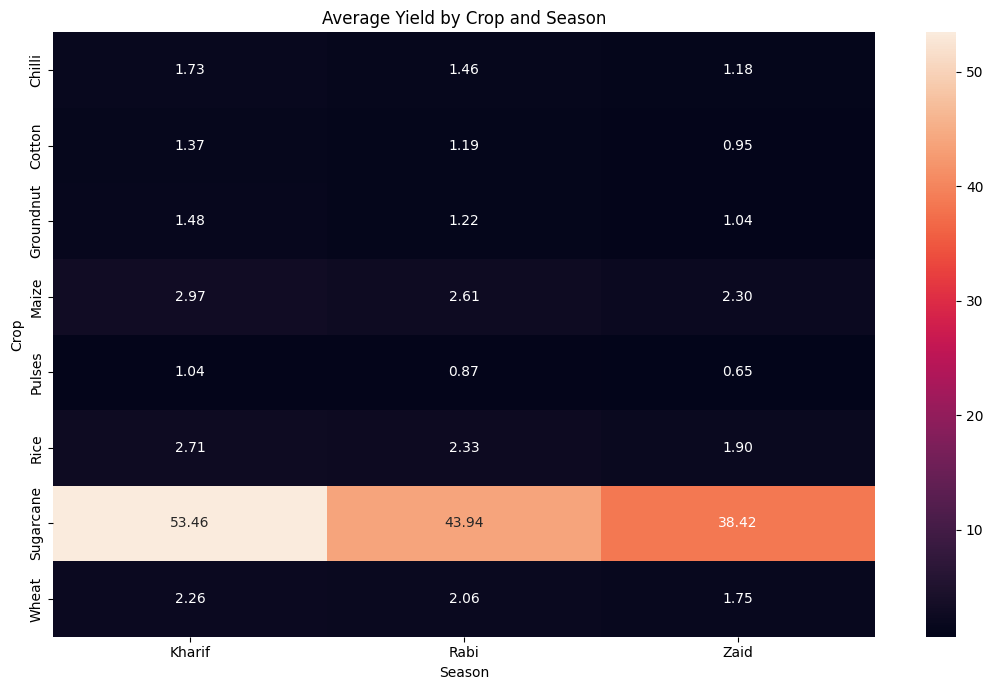

In [25]:
yield_pivot = crop_season.pivot(
    index="Crop",
    columns="Season",
    values="Average_Yield"
)

plt.figure(figsize=(11, 7))

sns.heatmap(
    yield_pivot,
    annot=True,
    fmt=".2f"
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()

plt.savefig("09_crop_season_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Regional Seasonal Comparison

In [26]:
regional_analysis = (
    df.groupby(["State", "Season"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Production=("Production_Tonnes", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .round(2)
    .reset_index()
)

display(regional_analysis)

,State,Season,Average_Yield,Average_Production,Average_Profit
0,Andhra Pradesh,Kharif,5.69,46.23,169315.52
1,Andhra Pradesh,Rabi,3.49,26.53,26315.71
2,Andhra Pradesh,Zaid,4.48,35.53,-84084.87
3,Gujarat,Kharif,6.34,54.53,217051.33
4,Gujarat,Rabi,5.52,47.55,82846.20
5,Gujarat,Zaid,4.10,30.20,-106929.61
6,Karnataka,Kharif,6.52,56.39,201226.21
7,Karnataka,Rabi,4.61,37.11,70952.61
8,Karnataka,Zaid,6.62,52.86,23310.91
9,Madhya Pradesh,Kharif,6.00,43.81,134242.40


Visualization

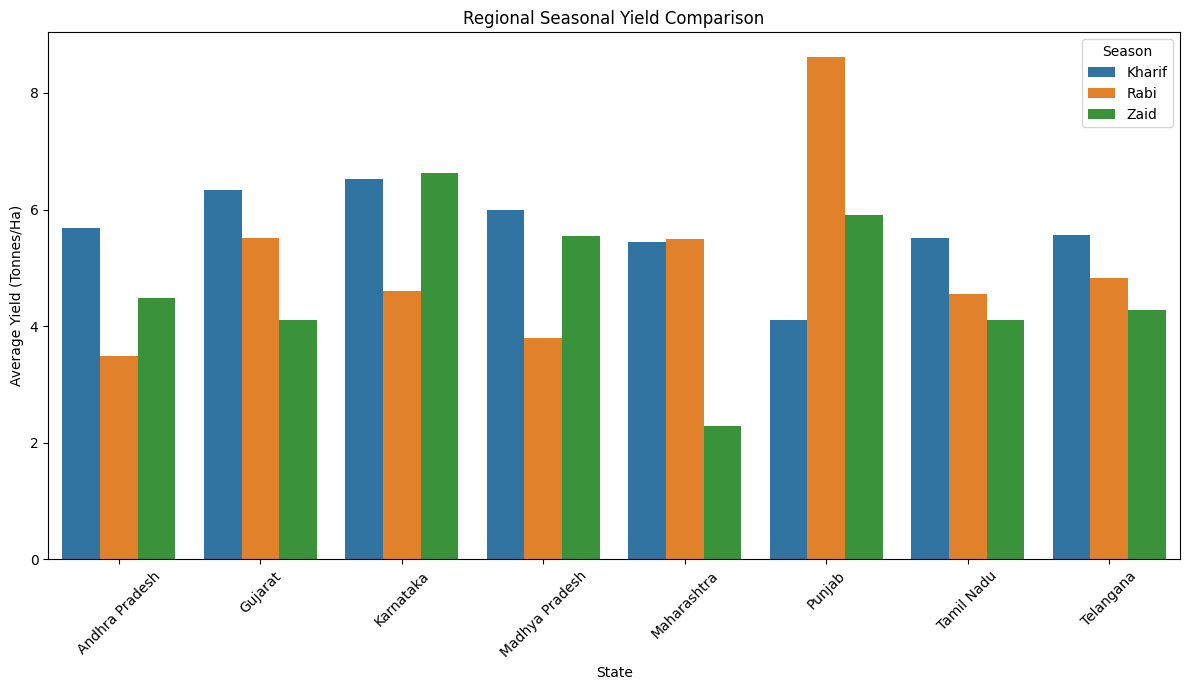

In [27]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=regional_analysis,
    x="State",
    y="Average_Yield",
    hue="Season"
)

plt.title("Regional Seasonal Yield Comparison")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("10_regional_seasonal_yield.png", dpi=300, bbox_inches="tight")
plt.show()

Correlation Analysis

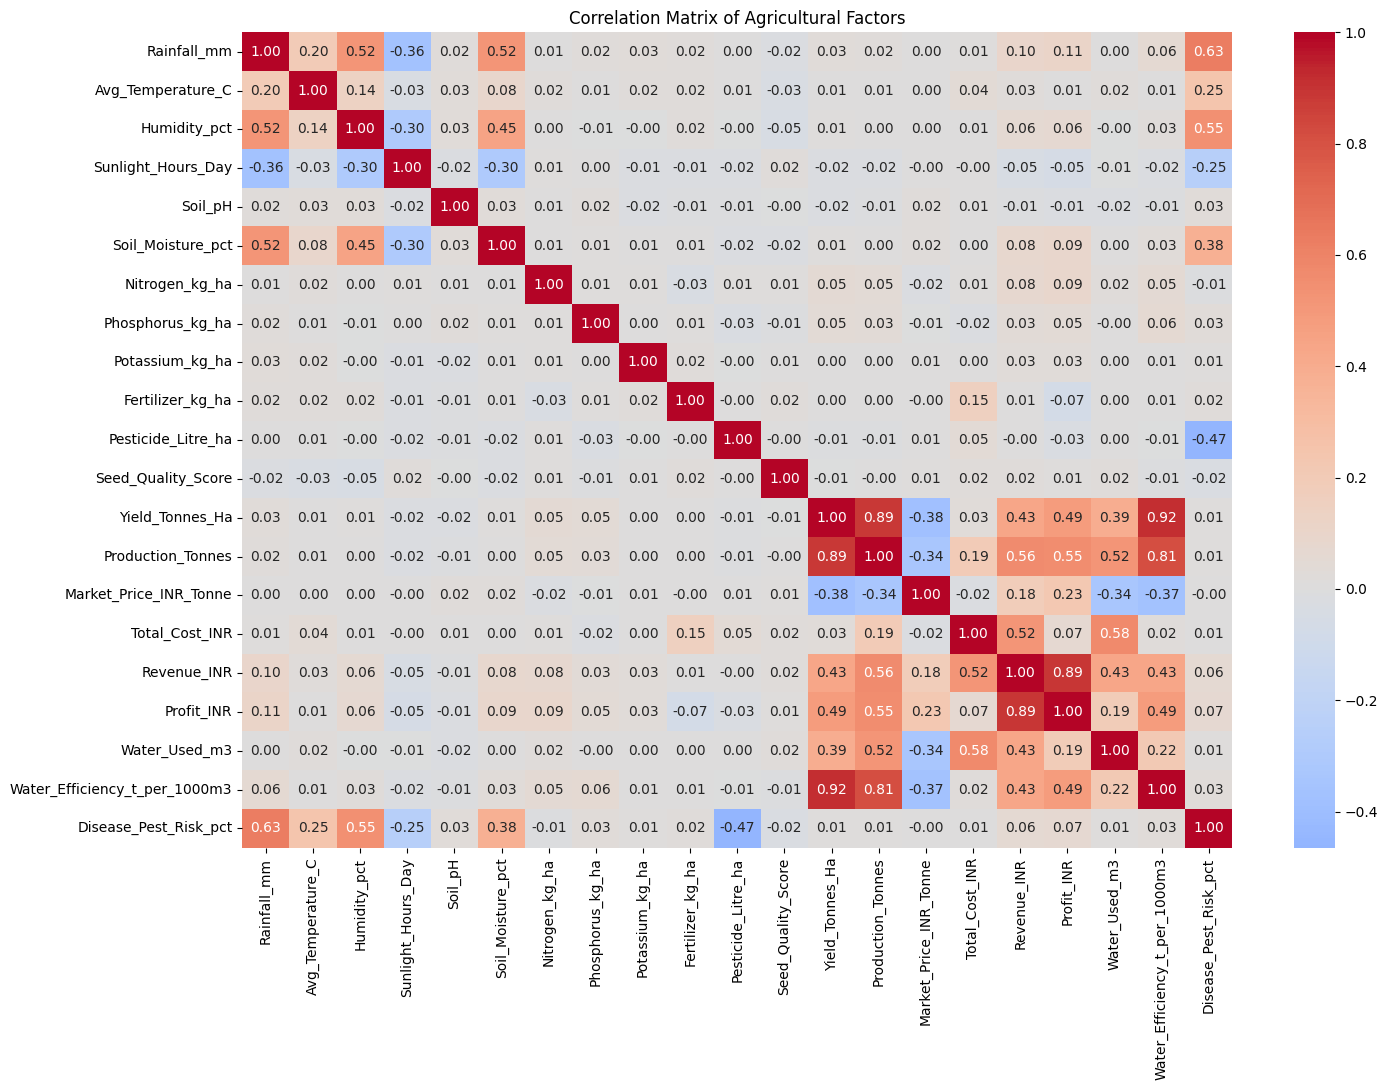

In [28]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Factors")
plt.tight_layout()

plt.savefig("11_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Disease and Pest Risk

In [29]:
risk_analysis = (
    df.groupby("Season")
    .agg(
        Average_Risk=("Disease_Pest_Risk_pct", "mean"),
        Maximum_Risk=("Disease_Pest_Risk_pct", "max")
    )
    .round(2)
    .reset_index()
)

display(risk_analysis)

,Season,Average_Risk,Maximum_Risk
0,Kharif,54.47,88.9
1,Rabi,40.48,71.2
2,Zaid,38.22,71.6


Visualization

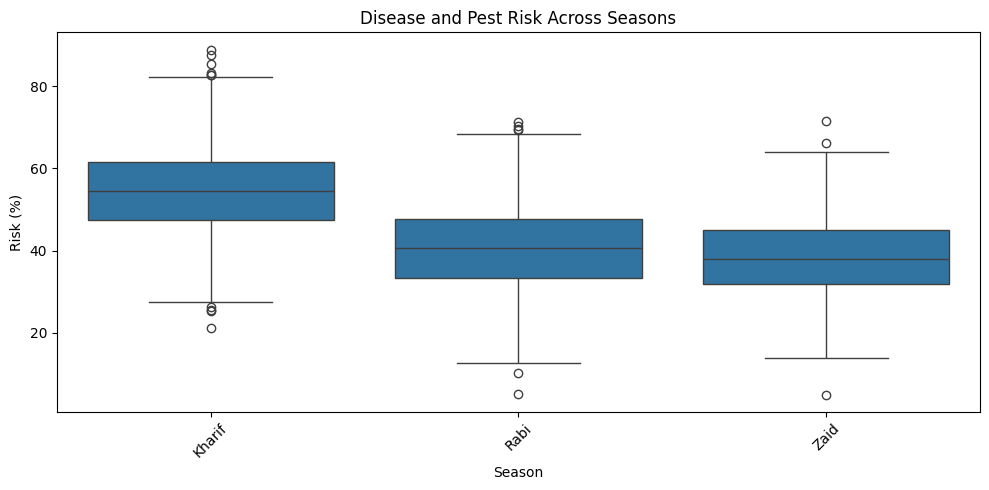

In [30]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct"
)

plt.title("Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("12_disease_pest_risk.png", dpi=300, bbox_inches="tight")
plt.show()

Automatically Find Best and Lowest Performing Seasons

In [31]:
best_season = seasonal_performance.loc[
    seasonal_performance["Average_Yield"].idxmax()
]

lowest_season = seasonal_performance.loc[
    seasonal_performance["Average_Yield"].idxmin()
]

print("===== HIGHEST PERFORMING SEASON =====")
print(best_season)

print("\n===== LOWEST PERFORMING SEASON =====")
print(lowest_season)

===== HIGHEST PERFORMING SEASON =====
Season                   Kharif
Average_Yield              5.64
Average_Production        46.31
Average_Profit        178914.65
Name: 0, dtype: object

===== LOWEST PERFORMING SEASON =====
Season                    Zaid
Average_Yield             4.67
Average_Production       38.89
Average_Profit       -24804.82
Name: 2, dtype: object


Find Best Crop + Season Combination

In [32]:
top_crop_seasons = (
    df.groupby(["Crop", "Season"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("Average_Yield", ascending=False)
)

print("Top 10 Crop-Season Combinations:")
display(top_crop_seasons.head(10))

Top 10 Crop-Season Combinations:


,Crop,Season,Average_Yield,Average_Profit
18,Sugarcane,Kharif,53.46,1000790.81
19,Sugarcane,Rabi,43.94,731612.86
20,Sugarcane,Zaid,38.42,583635.80
9,Maize,Kharif,2.97,-39332.67
15,Rice,Kharif,2.71,-64903.40
10,Maize,Rabi,2.61,-89133.40
16,Rice,Rabi,2.33,-98427.87
11,Maize,Zaid,2.30,-194049.17
21,Wheat,Kharif,2.26,-105871.87
22,Wheat,Rabi,2.06,-119954.57


Final Seasonal Summary

In [33]:
final_summary = (
    df.groupby("Season")
    .agg(
        Yield=("Yield_Tonnes_Ha", "mean"),
        Production=("Production_Tonnes", "mean"),
        Water_Use=("Water_Used_m3", "mean"),
        Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Cost=("Total_Cost_INR", "mean"),
        Revenue=("Revenue_INR", "mean"),
        Profit=("Profit_INR", "mean"),
        Disease_Risk=("Disease_Pest_Risk_pct", "mean")
    )
    .round(2)
)

display(final_summary)

,Yield,Production,Water_Use,Water_Efficiency,Cost,Revenue,Profit,Disease_Risk
Season,,,,,,,,
Kharif,5.64,46.31,6102.20,5.89,531804.41,710719.06,178914.65,54.47
Rabi,5.08,41.49,5846.99,5.19,513836.58,601526.05,87689.47,40.48
Zaid,4.67,38.89,6419.89,4.41,543976.73,519171.90,-24804.82,38.22
